# Student Performance Classification and Model Evaluation

This project examines a synthetic student-performance classification problem and develops the workflow from data exploration through model evaluation.

The analysis covers binary classification, decision-boundary interpretation, a custom Nearest-Mean classifier, confusion matrices, precision, recall, F1 score, multiclass evaluation, and metric implementations built directly with NumPy.

## 1. Setup

NumPy and Matplotlib support numerical analysis and visualization, while scikit-learn provides dataset generation, classification models, and evaluation utilities.

In [1]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

## 2. Binary Classification Dataset

A reproducible two-feature dataset is generated to represent student performance. The two numerical features correspond to exam scores, while the target is converted to a binary outcome.

In [2]:
# Create artificial dataset with two features
X, y = make_blobs(n_samples = [20,40,40,100],random_state=2, centers = [[35,30],[40,60],[70,40],[65,80]],cluster_std = [10,10,10,15])
y = np.int16(y==3)
print(f'{X.shape =}, {y.shape=}')

X.shape =(200, 2), y.shape=(200,)


### Inspecting the Feature Matrix and Target

In [3]:
X[:10]

array([[ 78.97831037, 102.02498199],
       [ 85.75671552,  82.22523865],
       [ 38.10530735,  59.22781335],
       [ 68.85578703,  35.01825806],
       [ 48.51054036,  69.77704033],
       [ 62.49246838,  71.35083605],
       [ 77.51964849,  30.06239017],
       [ 36.86491803,  67.71011738],
       [ 49.07951384,  78.37224764],
       [ 43.81866234,  65.66275441]])

In [4]:
y[:10]

array([1, 1, 0, 0, 1, 1, 0, 0, 1, 0], dtype=int16)

## 3. Feature-Space Visualization

The class distribution is visualized in the two-dimensional feature space before model training.

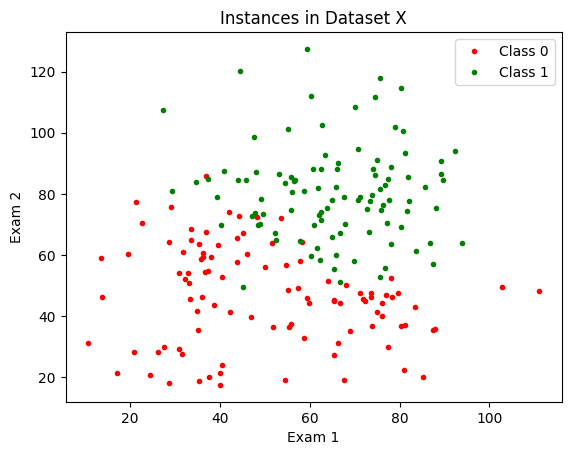

In [5]:
colors = 'rg'
classes = sorted(set(y))
plt.figure()
for c in classes:
  ind = (y==c)
  plt.plot(X[ind,0],X[ind,1],'.'+colors[c],label = 'Class '+str(c))
plt.xlabel("Exam 1")
plt.ylabel("Exam 2")
plt.legend()
plt.title('Instances in Dataset X')
plt.show()

## 4. Baseline Classifier Comparison

Three classification approaches are evaluated using the same train/test split:

- Logistic Regression
- 1-Nearest Neighbor
- Decision Tree

Decision boundaries are shown for both training and test data, followed by accuracy on each split.

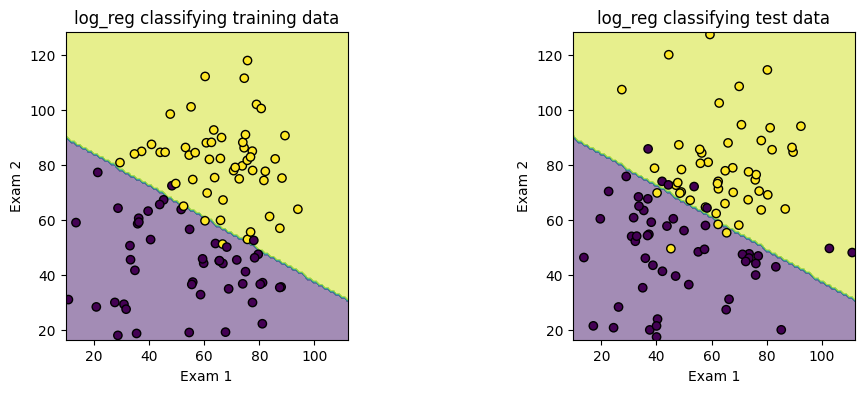

Prediction accuracy on training set: 0.9500
Prediction accuracy on test set:     0.8900


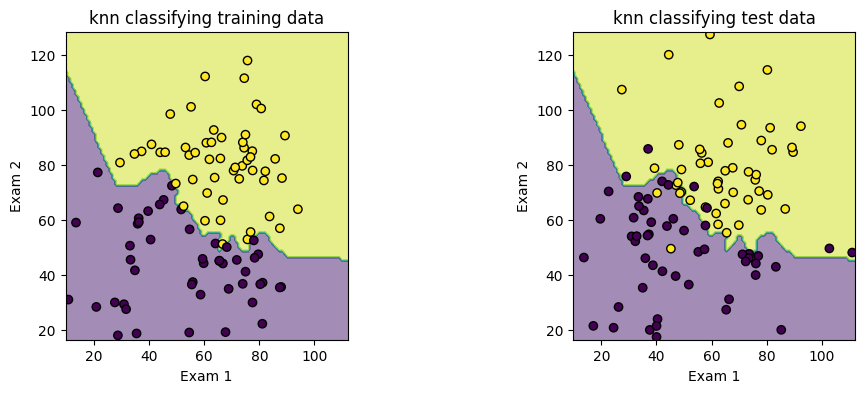

Prediction accuracy on training set: 1.0000
Prediction accuracy on test set:     0.8600


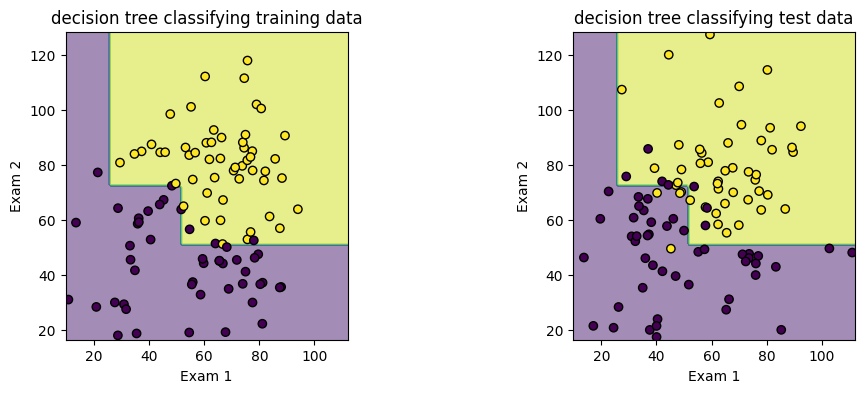

Prediction accuracy on training set: 0.9700
Prediction accuracy on test set:     0.8900


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)
classifiers = {'log_reg' : LogisticRegression(),
               'knn': KNeighborsClassifier(n_neighbors=1,weights='distance'),
               'decision tree': DecisionTreeClassifier(max_depth=3)}

for c in classifiers:
    classifier = classifiers[c]
    classifier.fit(X_train, y_train)

    fig, ax = plt.subplots(1,2,figsize=(12, 4))

    disp = DecisionBoundaryDisplay.from_estimator(
      classifier, X, response_method="predict",
      xlabel="Exam 1", ylabel="Exam 2",ax=ax[0],alpha=0.5)
    disp.ax_.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor="k")
    ax[0].set_title(c+' classifying training data')
    ax[0].set_aspect('equal')

    disp = DecisionBoundaryDisplay.from_estimator(
      classifier, X, response_method="predict",
      xlabel="Exam 1", ylabel="Exam 2",ax=ax[1],alpha=0.5)
    disp.ax_.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor="k")
    ax[1].set_title(c+' classifying test data')
    ax[1].set_aspect('equal')
    plt.show()

    pred = classifier.predict(X_train)
    print(f'Prediction accuracy on training set: {accuracy_score(y_train,pred):6.4f}')
    pred = classifier.predict(X_test)
    print(f'Prediction accuracy on test set:     {accuracy_score(y_test,pred):6.4f}')

### Model Behavior

The comparison highlights the difference between fitting the training data and generalizing to unseen observations. The 1-Nearest Neighbor model, for example, can fit the training set very closely while achieving lower test performance.

## 5. Custom Nearest-Mean Classifier

A Nearest-Mean classifier is implemented directly with NumPy. The model computes the mean feature vector for each class and predicts the class whose mean is closest in Euclidean distance.

In [7]:
class NearestMean:

    def __init__(self):
      return

    def fit(self,X,y):
      self.mean_0 = np.mean(X[y==0],axis=0)
      self.mean_1 = np.mean(X[y==1],axis=0)

    def predict(self,X):
      d0 = np.sqrt(np.sum((X-self.mean_0)**2,axis=1))
      d1 = np.sqrt(np.sum((X-self.mean_1)**2,axis=1))
      return np.int16(d1<d0)

X, y = make_blobs(n_samples = [20,40,40,100],centers = [[35,30],[40,60],[70,40],[65,80]],cluster_std = [10,10,10,15])
y = np.int16(y==3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

classifier = NearestMean()
classifier.fit(X_train, y_train)

print(classifier.mean_0)
print(classifier.mean_1)

pred = classifier.predict(X_train)
print(f'Prediction accuracy on training set: {accuracy_score(y_train,pred):6.4f}')
pred = classifier.predict(X_test)
print(f'Prediction accuracy on test set:     {accuracy_score(y_test,pred):6.4f}')

[51.01193989 45.77568839]
[65.47065882 75.60169895]
Prediction accuracy on training set: 0.8700
Prediction accuracy on test set:     0.9600


## 6. Binary Classification Performance Metrics

Accuracy alone does not describe every type of classification error. Binary classification can also be interpreted through:

- **True Positive (TP):** positive instance predicted as positive
- **True Negative (TN):** negative instance predicted as negative
- **False Positive (FP):** negative instance predicted as positive
- **False Negative (FN):** positive instance predicted as negative

These quantities support precision, recall, F1 score, and the confusion matrix.

### Evaluating Models with Multiple Metrics

A second binary dataset is used to compare the same classifiers using confusion matrices, accuracy, precision, recall, and F1 score.

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

X, y = make_blobs(n_samples = [60,120,140,100],random_state=2, centers = [[35,30],[40,60],[70,40],[65,80]],cluster_std = [10,10,10,15])
y = np.int16(y==3)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)
classifiers = {'log_reg' : LogisticRegression(),
               'knn': KNeighborsClassifier(n_neighbors=1,weights='distance'),
               'decision tree': DecisionTreeClassifier(max_depth=3)}

for c in classifiers:
    print(f'Classifier: {c}')
    classifier = classifiers[c]
    classifier.fit(X_train, y_train)
    pred = classifier.predict(X_test)
    print(f'Confusion matrix:\n{confusion_matrix(y_test,pred)}')
    print(f'Accuracy: {accuracy_score(y_test,pred):6.4f}')
    print(f'Precision: {precision_score(y_test,pred):6.4f}')
    print(f'Recall: {recall_score(y_test,pred):6.4f}')
    print(f'F1: {f1_score(y_test,pred):6.4f}')
    print()

Classifier: log_reg
Confusion matrix:
[[157   6]
 [ 13  34]]
Accuracy: 0.9095
Precision: 0.8500
Recall: 0.7234
F1: 0.7816

Classifier: knn
Confusion matrix:
[[155   8]
 [  7  40]]
Accuracy: 0.9286
Precision: 0.8333
Recall: 0.8511
F1: 0.8421

Classifier: decision tree
Confusion matrix:
[[158   5]
 [  7  40]]
Accuracy: 0.9429
Precision: 0.8889
Recall: 0.8511
F1: 0.8696



## 7. Multiclass Confusion Matrices

For multiclass classification, the confusion matrix remains useful because each row represents the actual class and each column represents the predicted class.

In [9]:
y =    [0,0,1,1,2,2,3,3]
pred = [0,1,1,2,3,2,3,3]
print(f'Confusion matrix:\n{confusion_matrix(y,pred)}')

Confusion matrix:
[[1 1 0 0]
 [0 1 1 0]
 [0 0 1 1]
 [0 0 0 2]]


### Multiclass Model Comparison

The target is expanded to four classes, and the three classifiers are evaluated using decision boundaries, accuracy, and a multiclass confusion matrix.

Classifier: log_reg


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


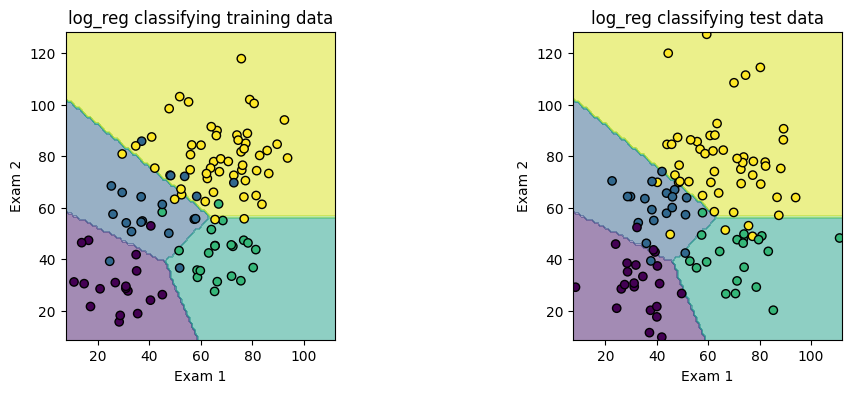

Prediction accuracy on training set: 0.8455
Prediction accuracy on test set:     0.9000
Confusion matrix:
[[19  3  0  0]
 [ 1 17  1  0]
 [ 0  1 19  0]
 [ 0  2  3 44]]
Classifier: knn


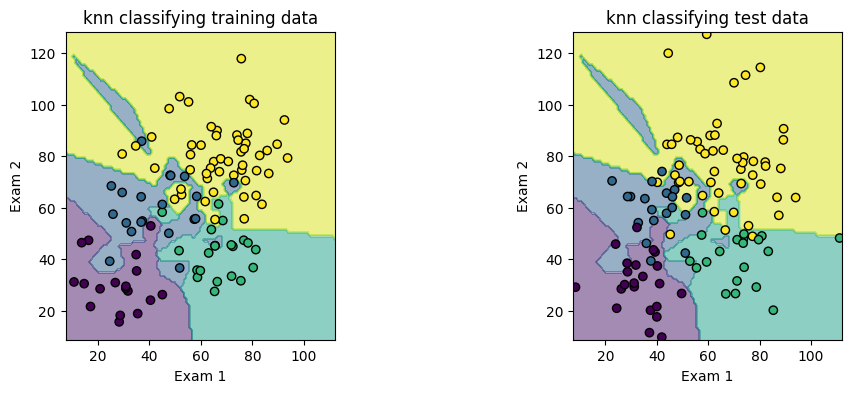

Prediction accuracy on training set: 1.0000
Prediction accuracy on test set:     0.7727
Confusion matrix:
[[19  3  0  0]
 [ 2 11  2  4]
 [ 0  3 17  0]
 [ 0  8  3 38]]
Classifier: decision tree


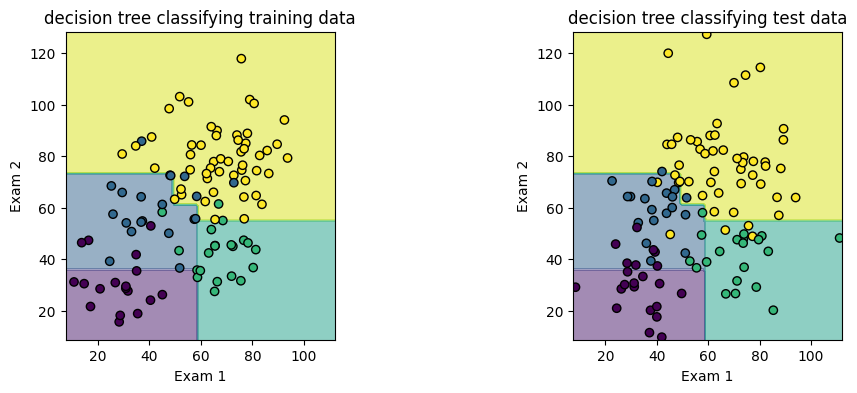

Prediction accuracy on training set: 0.8909
Prediction accuracy on test set:     0.8091
Confusion matrix:
[[15  7  0  0]
 [ 0 17  0  2]
 [ 0  4 16  0]
 [ 0  5  3 41]]


In [10]:
X, y = make_blobs(n_samples = [40,40,40,100],random_state=2, centers = [[35,30],[40,60],[70,40],[65,80]],cluster_std = [10,10,10,15])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)
classifiers = {'log_reg' : LogisticRegression(),
               'knn': KNeighborsClassifier(n_neighbors=1,weights='distance'),
               'decision tree': DecisionTreeClassifier(max_depth=3)}

for c in classifiers:
    print(f'Classifier: {c}')
    classifier = classifiers[c]
    classifier.fit(X_train, y_train)

    fig, ax = plt.subplots(1,2,figsize=(12, 4))

    disp = DecisionBoundaryDisplay.from_estimator(
      classifier, X, response_method="predict",
      xlabel="Exam 1", ylabel="Exam 2",ax=ax[0],alpha=0.5)
    disp.ax_.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor="k")
    ax[0].set_title(c+' classifying training data')
    ax[0].set_aspect('equal')

    disp = DecisionBoundaryDisplay.from_estimator(
      classifier, X, response_method="predict",
      xlabel="Exam 1", ylabel="Exam 2",ax=ax[1],alpha=0.5)
    disp.ax_.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor="k")
    ax[1].set_title(c+' classifying test data')
    ax[1].set_aspect('equal')
    plt.show()

    pred = classifier.predict(X_train)
    print(f'Prediction accuracy on training set: {accuracy_score(y_train,pred):6.4f}')
    pred = classifier.predict(X_test)
    print(f'Prediction accuracy on test set:     {accuracy_score(y_test,pred):6.4f}')
    print(f'Confusion matrix:\n{confusion_matrix(y_test,pred)}')

## 8. Evaluation Metrics Implemented from Scratch

The core evaluation calculations are implemented directly with NumPy. Accuracy and the confusion matrix support multiple classes, while precision, recall, and F1 are implemented for binary classification.

Repeated imports were removed during organization, but the metric implementations and evaluation logic are preserved.

In [11]:
def accuracy(y,p):
  return  np.sum(y==p)/len(p)
  #return np.mean(y==p)

def precision(y,p):
  return np.sum(y*p)/np.sum(p)

def recall(y,p):
  return np.sum(y*p)/np.sum(y)

def f1_measure(y,p):
  return 2*precision(y,p)*recall(y,p)/(precision(y,p)+recall(y,p))

def confusion_mat(y,p):
  n_classes = np.max(y)+1
  m = np.zeros((n_classes,n_classes),dtype=np.int32)
  for i in range(len(y)):
    m[y[i],p[i]]+=1
  return m

X, y = make_blobs(n_samples = [20,40,40,100],random_state=2, centers = [[35,30],[40,60],[70,40],[65,80]],cluster_std = [10,10,10,15])
y = np.int16(y==3)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)
classifiers = {'log_reg' : LogisticRegression(),
               'knn': KNeighborsClassifier(n_neighbors=1,weights='distance'),
               'decision tree': DecisionTreeClassifier(max_depth=3)}

for c in classifiers:
    print(f'Classifier: {c}')
    classifier = classifiers[c]
    classifier.fit(X_train, y_train)
    pred = classifier.predict(X_test)
    print(f'Confusion matrix:\n{confusion_mat(y_test,pred)}')
    print(f'Accuracy: {accuracy(y_test,pred):6.4f}')
    print(f'Precision: {precision(y_test,pred):6.4f}')
    print(f'Recall: {recall(y_test,pred):6.4f}')
    print(f'F1: {f1_measure(y_test,pred):6.4f}')
    print()

Classifier: log_reg
Confusion matrix:
[[45  7]
 [ 4 44]]
Accuracy: 0.8900
Precision: 0.8627
Recall: 0.9167
F1: 0.8889

Classifier: knn
Confusion matrix:
[[45  7]
 [ 7 41]]
Accuracy: 0.8600
Precision: 0.8542
Recall: 0.8542
F1: 0.8542

Classifier: decision tree
Confusion matrix:
[[46  6]
 [ 5 43]]
Accuracy: 0.8900
Precision: 0.8776
Recall: 0.8958
F1: 0.8866



## 9. Technical Takeaways

This project connects model behavior with multiple evaluation measures and demonstrates both library-based and from-scratch implementations.

Technical components include decision-boundary visualization, train/test evaluation, nearest-mean classification, binary and multiclass confusion matrices, precision, recall, F1 score, and custom metric implementation with NumPy.